In [265]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import json
import os
import logging
from IPython.display import display


In [266]:
RAW_DATA_PATH = "data/raw/raw_movies.json"
PROCESSED_CSV_PATH = "data/processed/israeli_actors_edges.csv"
METRICS_OUTPUT_CSV = "data/processed/temporal_metrics_summary.csv"
METRICS_LATEX_PATH = "data/processed/temporal_metrics_table.tex"
DISTRIBUTION_PLOT_PATH = "data/processed/degree_distributions.png"
COMMUNITY_PROFILES_CSV = "data/processed/era_c_community_profiles.csv"
CENTRALITY_SUMMARY_CSV = "data/processed/actor_centralities.csv"
GEXF_PATH = "data/processed/israeli_actors_graph.gexf"
MODEL_METRICS_PATH = "data/processed/link_prediction_metrics.csv"

In [267]:

from src.scraper import get_category_members, fetch_page_wikitext
from src.parser import parse_movie_metadata
from src.graph_builder import build_co_star_graph, export_graph_data


os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# 1. Scraping / Fetching Raw Data
if not os.path.exists(RAW_DATA_PATH):
    members = get_category_members("קטגוריה:סרטים ישראליים")
    movie_data = []

    logging.info("Downloading wikitext for movie pages...")
    for idx, member in enumerate(members, 1):
        page_id = member["pageid"]
        title = member["title"]
        logging.info(f"[{idx}/{len(members)}] Processing: {title}")
        
        try:
            wikitext = fetch_page_wikitext(page_id)
            movie_data.append({
                "pageid": page_id,
                "title": title,
                "wikitext": wikitext
            })
        except Exception as e:
            logging.error(f"Failed to fetch {title}: {e}")

    with open(RAW_DATA_PATH, "w", encoding="utf-8") as f:
        json.dump(movie_data, f, ensure_ascii=False, indent=2)
else:
    logging.info(f"Loading cached raw data from {RAW_DATA_PATH}")
    with open(RAW_DATA_PATH, "r", encoding="utf-8") as f:
        movie_data = json.load(f)


2026-08-15 22:35:29,300 - INFO - Loading cached raw data from data/raw/raw_movies.json


In [268]:
# 2. Parsing Metadata & Actor Extraction
parsed_records = []
for item in movie_data:
    year, actors = parse_movie_metadata(item["wikitext"], max_actors=10)
    if year and len(actors) >= 2:
        parsed_records.append({
            "title": item["title"],
            "year": year,
            "actors": actors
        })

logging.info(f"Successfully extracted cast records for {len(parsed_records)} movies.")

2026-08-15 22:35:31,023 - INFO - Successfully extracted cast records for 27 movies.


In [269]:
# 3. Building Graph & Exporting
G = build_co_star_graph(parsed_records)
export_graph_data(G, PROCESSED_CSV_PATH, GEXF_PATH)

2026-08-15 22:35:31,033 - INFO - Graph Construction Complete: 116 Nodes, 314 Edges.
2026-08-15 22:35:31,396 - INFO - Exported edges CSV to data/processed/israeli_actors_edges.csv
2026-08-15 22:35:31,429 - INFO - Exported Gephi GEXF file to data/processed/israeli_actors_graph.gexf


In [270]:

# 1. Load the processed edge dataset
df_edges = pd.read_csv("./data/processed/israeli_actors_edges.csv")

# 2. Reconstruct the NetworkX graph
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(
        row["Source"], 
        row["Target"], 
        weight=row["Weight"], 
        first_year=row["First_CoStar_Year"],
        movies=row["Movies"]
    )

print(f"Graph loaded successfully: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")

Graph loaded successfully: 116 Nodes, 314 Edges


In [271]:
def draw_graph(graph,title="",figsize=None,draw_k_labels=25,itrations=20):
  pos = nx.spring_layout(graph, k=0.3, iterations=itrations, seed=42)

  # Calculate node size proportional to degree
  degrees = dict(graph.degree())
  node_sizes = [v * 15 for v in degrees.values()]
  if figsize is not None:
    plt.figure(figsize=figsize)
  else:  
    plt.figure()
  plt.title(title, fontsize=18, fontweight="bold")

  # Draw edges with transparency
  nx.draw_networkx_edges(graph, pos, alpha=0.15, edge_color="gray")

  # Draw nodes colored by degree intensity
  nodes = nx.draw_networkx_nodes(
      graph, 
      pos, 
      node_size=node_sizes, 
      node_color=list(degrees.values()), 
      cmap=plt.cm.viridis, 
      alpha=0.85,
      
  )

  # Label top-K most connected actors to prevent label clutter
  top_actors = sorted(degrees, key=degrees.get, reverse=True)[:draw_k_labels]
  labels = {node: node for node in top_actors}  # Reverse Hebrew strings for correct Matplotlib rendering
  nx.draw_networkx_labels(graph, pos, labels=labels, font_size=9, font_weight="bold")

  plt.colorbar(nodes, label="Degree (Number of Co-stars)")
  plt.axis("off")
  plt.tight_layout()
  plt.show()

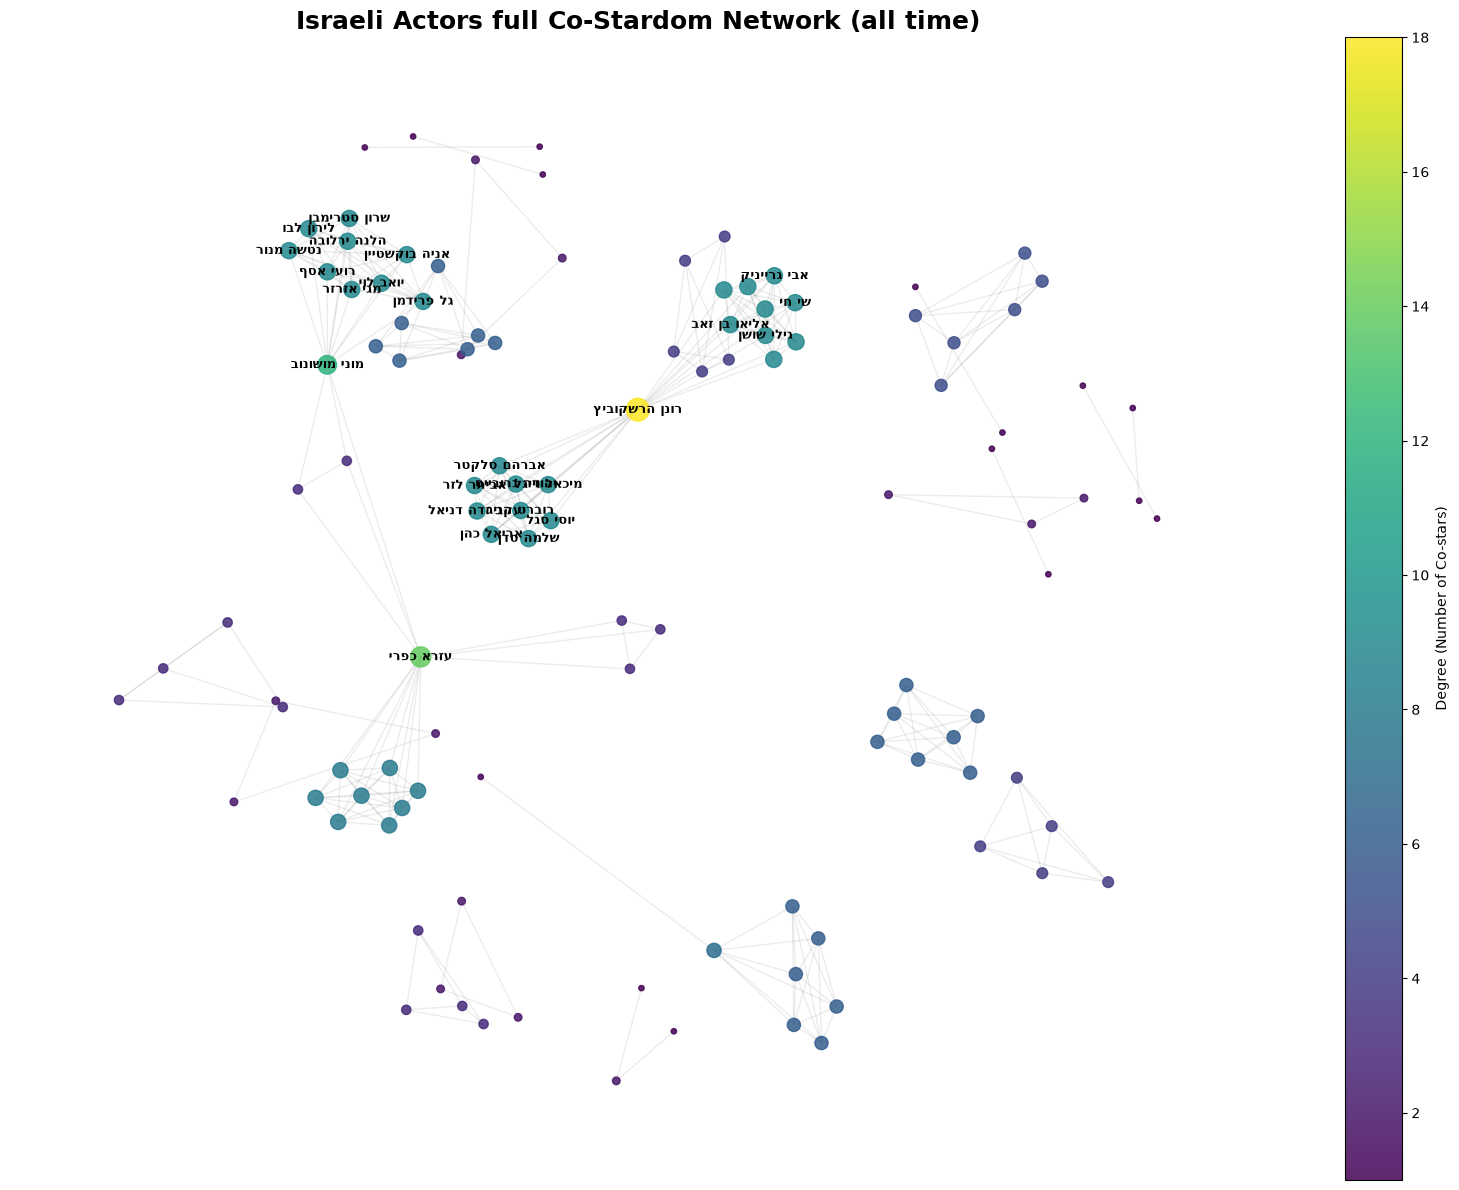

In [272]:
g = G.copy()

draw_graph(graph=g,title="Israeli Actors full Co-Stardom Network (all time)",figsize=(16,12),itrations=40)


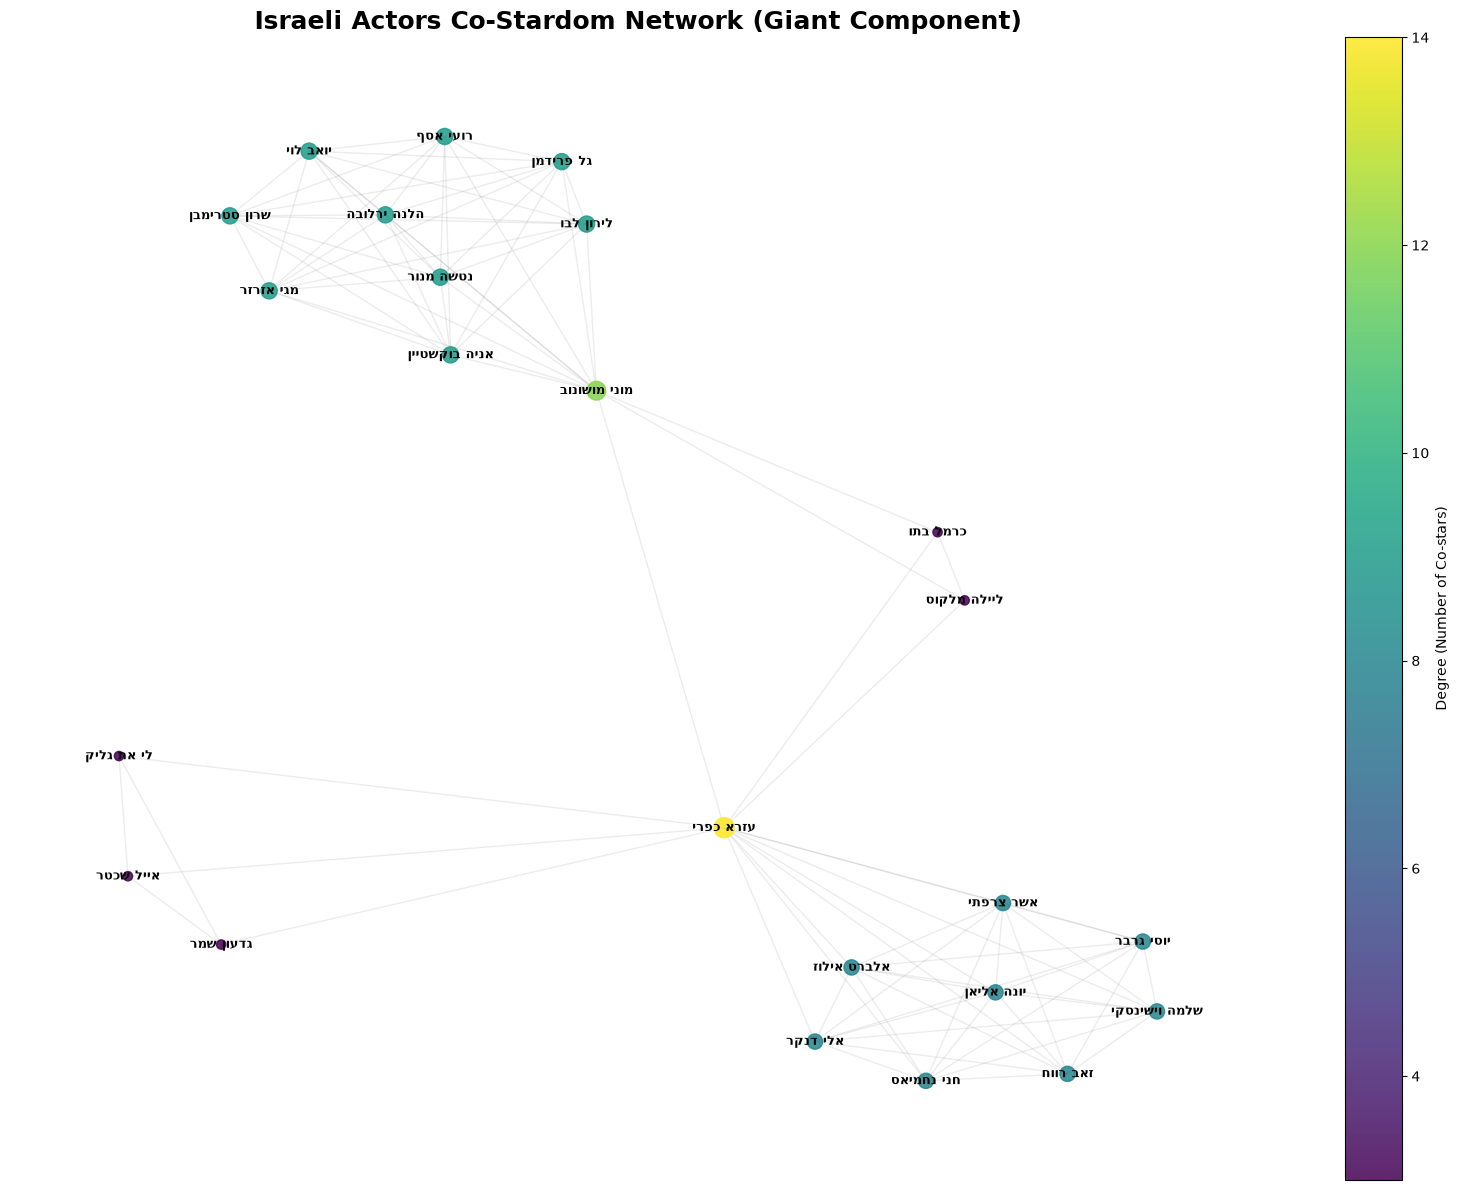

In [273]:
# Extract the Giant Connected Component (GCC) for clear visual output
gcc_nodes = max(nx.connected_components(G), key=len)
G_gcc = G.subgraph(gcc_nodes).copy()

draw_graph(G_gcc,"Israeli Actors Co-Stardom Network (Giant Component)",(16, 12))

In [274]:
from src.temporal_analysis import (
    split_graph_by_eras, 
    compute_era_metrics, 
    plot_degree_distributions
)


if not os.path.exists(PROCESSED_CSV_PATH):
    raise FileNotFoundError(f"Missing input dataset: {PROCESSED_CSV_PATH}. Run Step 1 first.")

logging.info("Loading processed edges dataset...")
df_edges = pd.read_csv(PROCESSED_CSV_PATH)

# 1. Segment graph into eras
subgraphs = split_graph_by_eras(df_edges)

# 2. Compute metrics for each era
metrics_list = []
for era_name, G_sub in subgraphs.items():
    metrics = compute_era_metrics(G_sub, era_name)
    metrics_list.append(metrics)

df_summary = pd.DataFrame(metrics_list)

# 3. Export Metric Tables
df_summary.to_csv(METRICS_OUTPUT_CSV, index=False)
logging.info(f"Exported metrics CSV to {METRICS_OUTPUT_CSV}")

# Generate LaTeX table snippet for direct inclusion in assignment PDF report
with open(METRICS_LATEX_PATH, "w") as f:
    f.write(df_summary.to_latex(index=False, caption="Temporal Metrics Comparison Across Eras", label="tab:temporal_metrics"))
logging.info(f"Exported LaTeX table to {METRICS_LATEX_PATH}")

# 4. Plot & Save Degree Distributions
plot_degree_distributions(subgraphs, DISTRIBUTION_PLOT_PATH)

print("\n" + "="*80)
print("TEMPORAL GRAPH ANALYSIS SUMMARY")
print("="*80)
print(df_summary.to_string(index=False))
print("="*80 + "\n")


2026-08-15 22:35:32,385 - INFO - Loading processed edges dataset...
2026-08-15 22:35:32,539 - INFO - Sub-graph Era_A_Pre1970: 8 Nodes, 13 Edges
2026-08-15 22:35:32,544 - INFO - Sub-graph Era_B_1970_1990: 32 Nodes, 94 Edges
2026-08-15 22:35:32,553 - INFO - Sub-graph Era_C_1990_Present: 77 Nodes, 207 Edges
2026-08-15 22:35:32,559 - INFO - Exported metrics CSV to data/processed/temporal_metrics_summary.csv
2026-08-15 22:35:32,762 - INFO - Exported LaTeX table to data/processed/temporal_metrics_table.tex
2026-08-15 22:35:34,007 - INFO - Exported degree distribution plot to data/processed/degree_distributions.png



TEMPORAL GRAPH ANALYSIS SUMMARY
               Era  Nodes (|V|)  Edges (|E|)  Density  Avg Clustering (C)  Num CC  GCC Size  GCC Ratio  GCC Radius  GCC Diameter  Avg Degree <k>  Max Degree
     Era_A_Pre1970            8           13  0.46429              1.0000       2         5     0.6250           1             1            3.25           4
   Era_B_1970_1990           32           94  0.18952              1.0000       5         9     0.2812           1             1            5.88           8
Era_C_1990_Present           77          207  0.07075              0.7685      15        19     0.2468           1             2            5.38          18



In [275]:
from src.temporal_analysis import split_graph_by_eras, compute_era_metrics

# Load data and build subgraphs
df_edges = pd.read_csv("./data/processed/israeli_actors_edges.csv")
subgraphs = split_graph_by_eras(df_edges)

# Calculate metrics across Eras
metrics_data = [compute_era_metrics(G_sub, era_name) for era_name, G_sub in subgraphs.items()]
df_metrics = pd.DataFrame(metrics_data)

# Display tabular output
df_metrics.style.set_caption("Temporal Graph Development Metrics").highlight_max(axis=0, color="green")


2026-08-15 22:35:34,035 - INFO - Sub-graph Era_A_Pre1970: 8 Nodes, 13 Edges
2026-08-15 22:35:34,044 - INFO - Sub-graph Era_B_1970_1990: 32 Nodes, 94 Edges


2026-08-15 22:35:34,090 - INFO - Sub-graph Era_C_1990_Present: 77 Nodes, 207 Edges


,Era,Nodes (|V|),Edges (|E|),Density,Avg Clustering (C),Num CC,GCC Size,GCC Ratio,GCC Radius,GCC Diameter,Avg Degree,Max Degree
0,Era_A_Pre1970,8,13,0.464290,1.000000,2,5,0.625000,1,1,3.250000,4
1,Era_B_1970_1990,32,94,0.189520,1.000000,5,9,0.281200,1,1,5.880000,8
2,Era_C_1990_Present,77,207,0.070750,0.768500,15,19,0.246800,1,2,5.380000,18


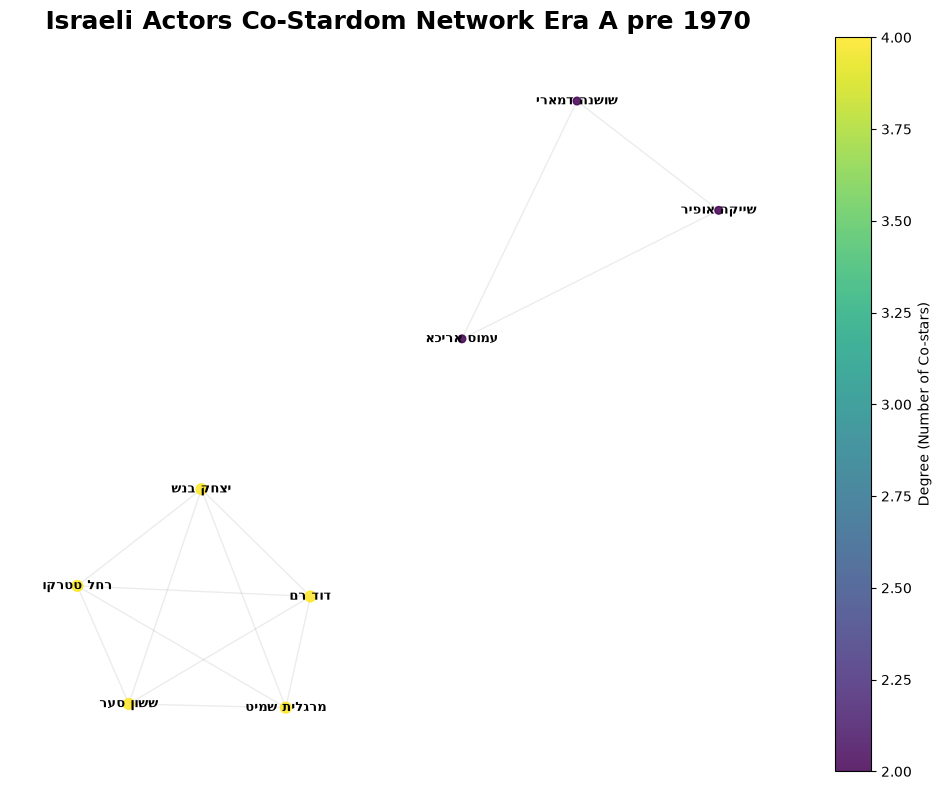

In [276]:
#draw Era_A
era_a = subgraphs["Era_A_Pre1970"].copy()
draw_graph(era_a,"Israeli Actors Co-Stardom Network Era A pre 1970",(10,8))

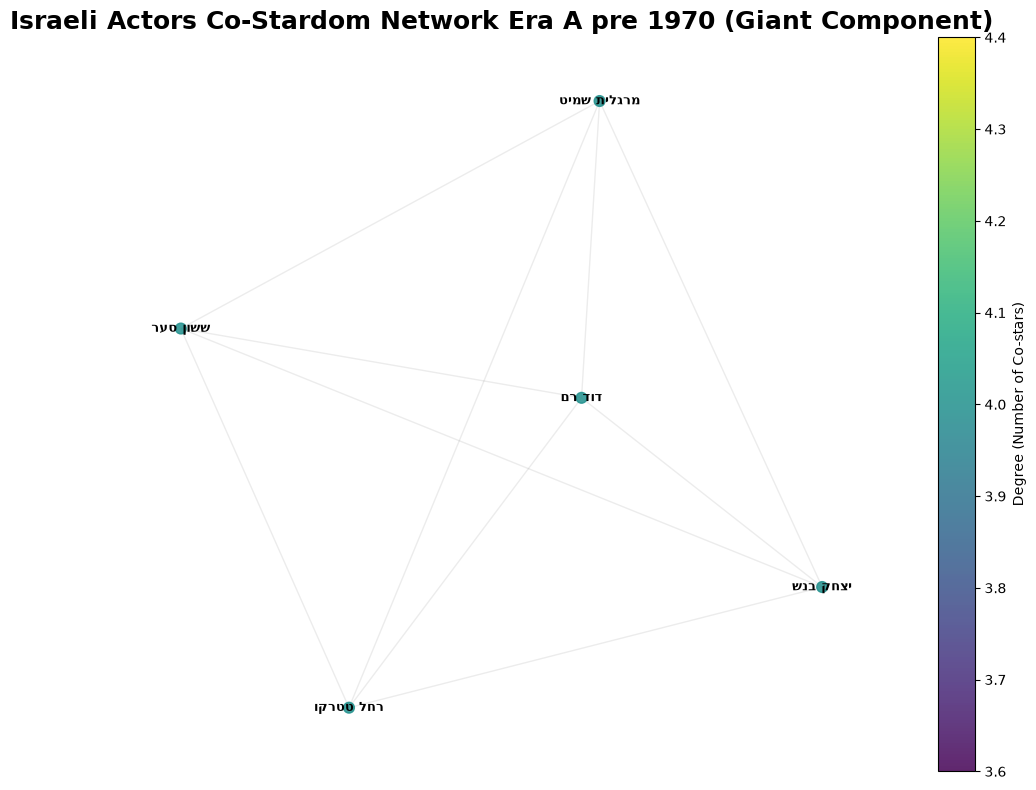

In [277]:
G_gcc_a = max(nx.connected_components(era_a), key=len)
gcc_a= G.subgraph(G_gcc_a).copy()

draw_graph(gcc_a,"Israeli Actors Co-Stardom Network Era A pre 1970 (Giant Component)",(10,8))

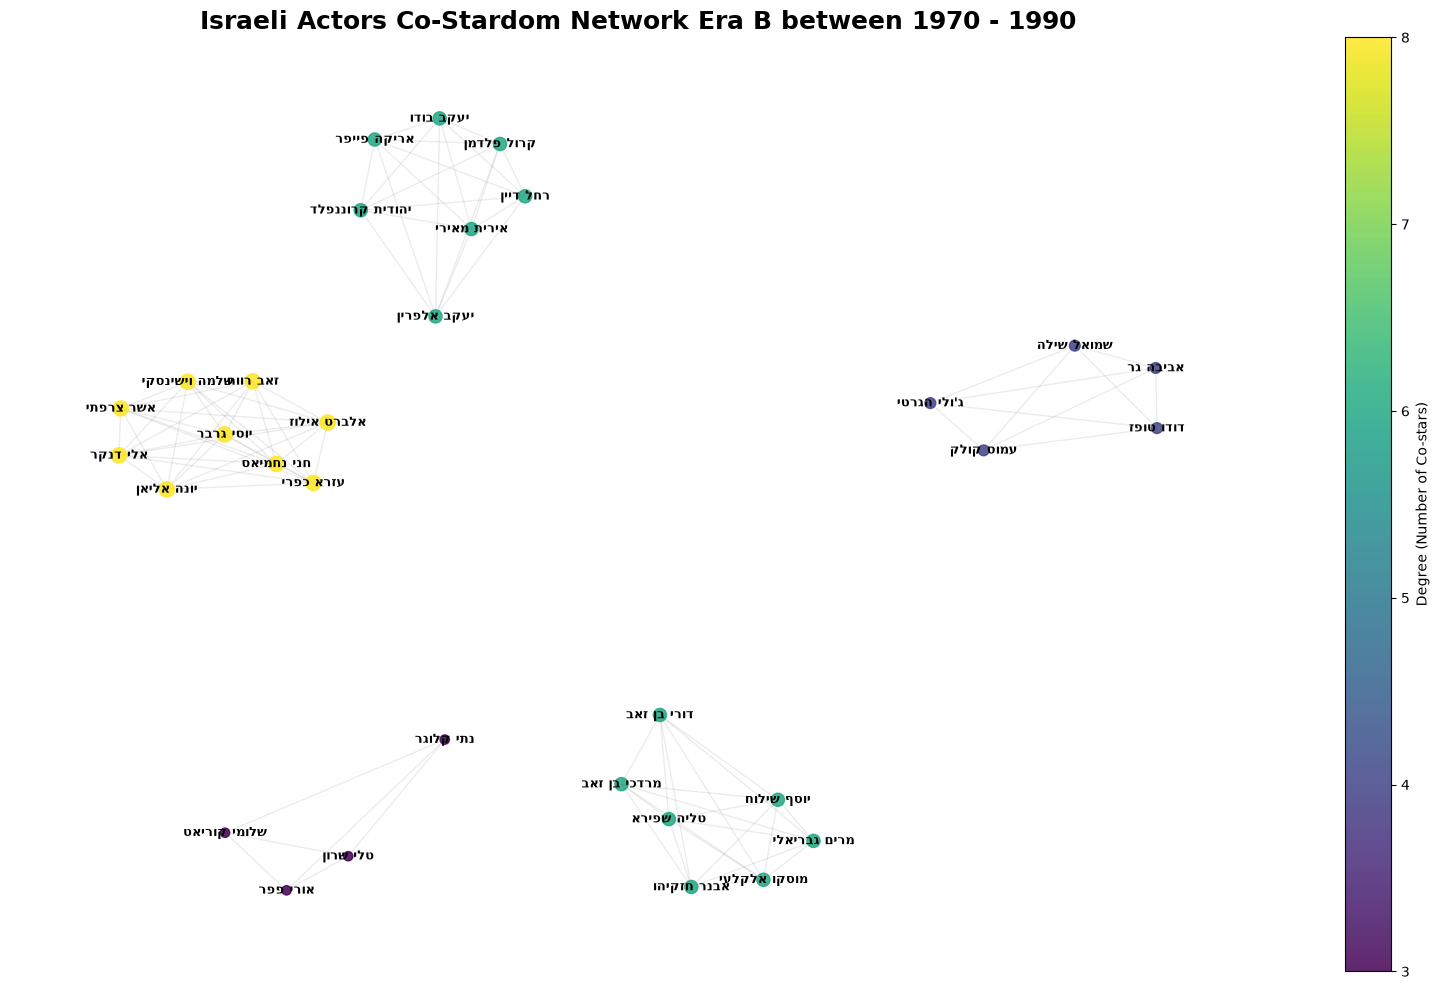

In [278]:
era_b = subgraphs["Era_B_1970_1990"].copy()
draw_graph(era_b,"Israeli Actors Co-Stardom Network Era B between 1970 - 1990",(16,10),40)

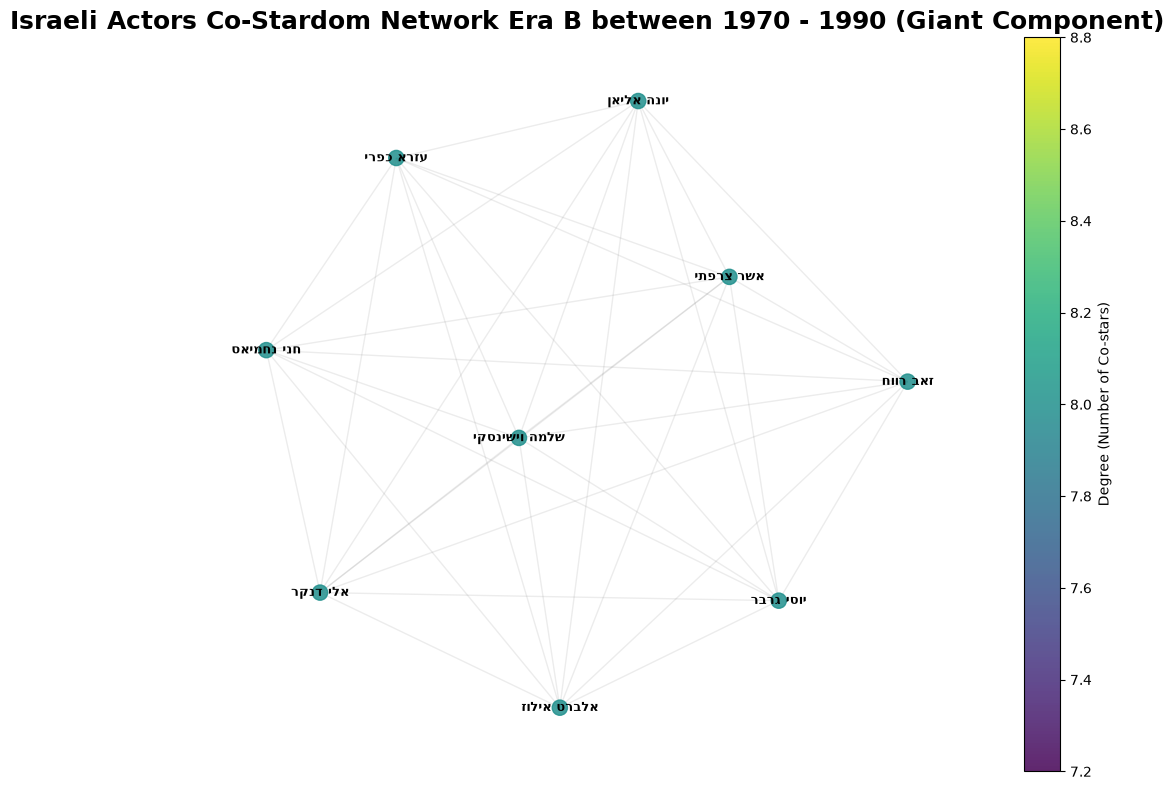

In [279]:
G_gcc_b = max(nx.connected_components(era_b), key=len)
gcc_b= G.subgraph(G_gcc_b).copy()

draw_graph(gcc_b,"Israeli Actors Co-Stardom Network Era B between 1970 - 1990 (Giant Component)",(10,8))

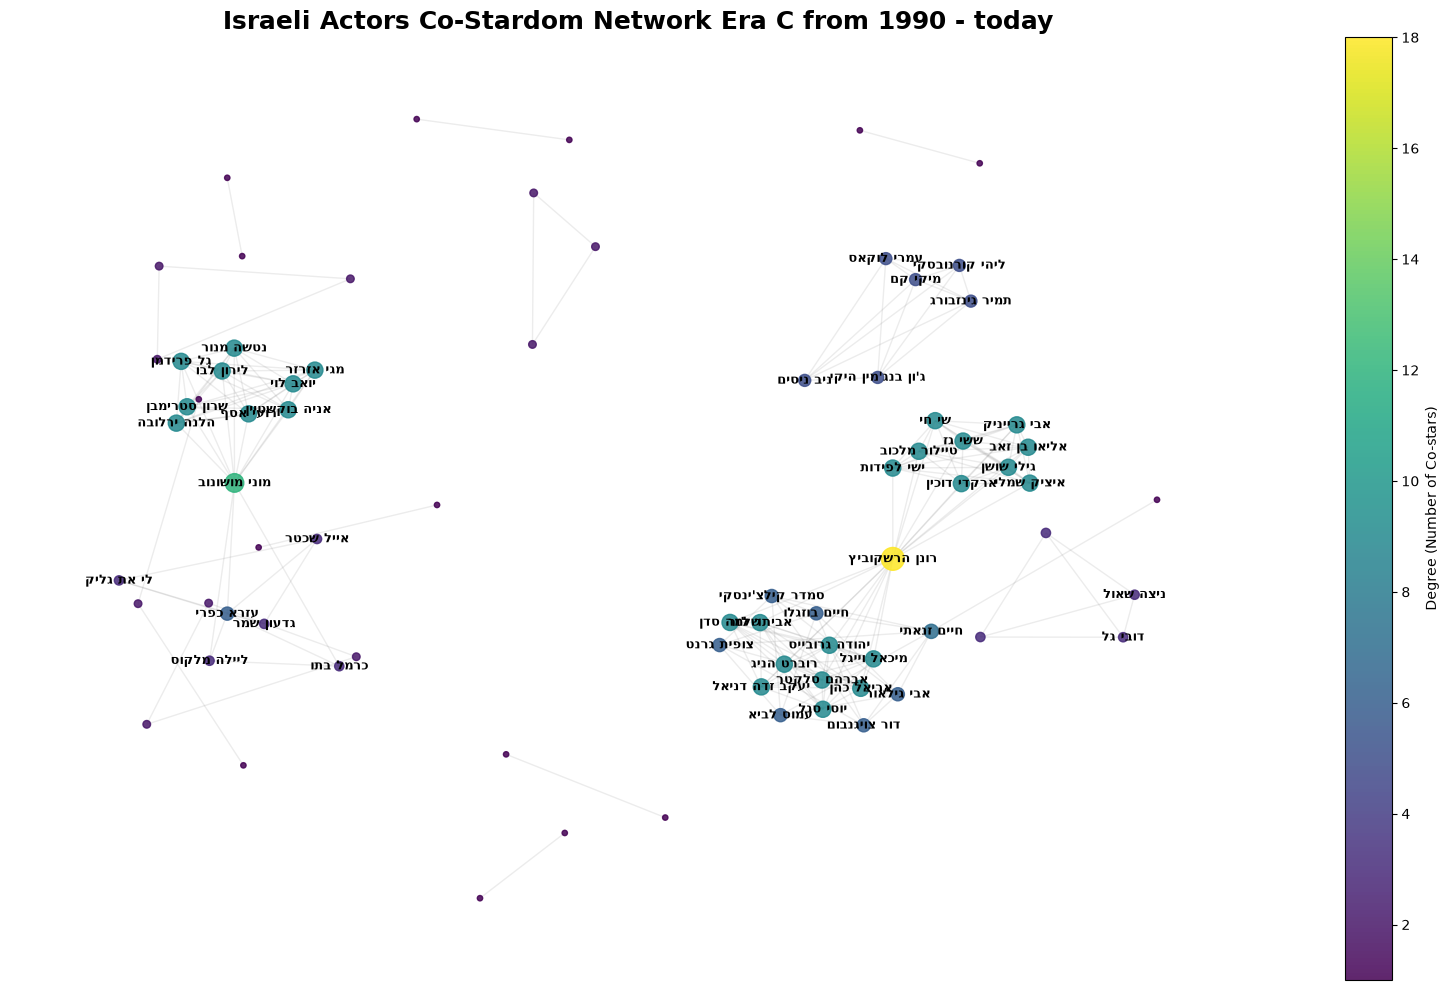

In [280]:
era_c = subgraphs["Era_C_1990_Present"].copy()
draw_graph(era_c,title="Israeli Actors Co-Stardom Network Era C from 1990 - today",figsize=(16,10),draw_k_labels=50,itrations=30)

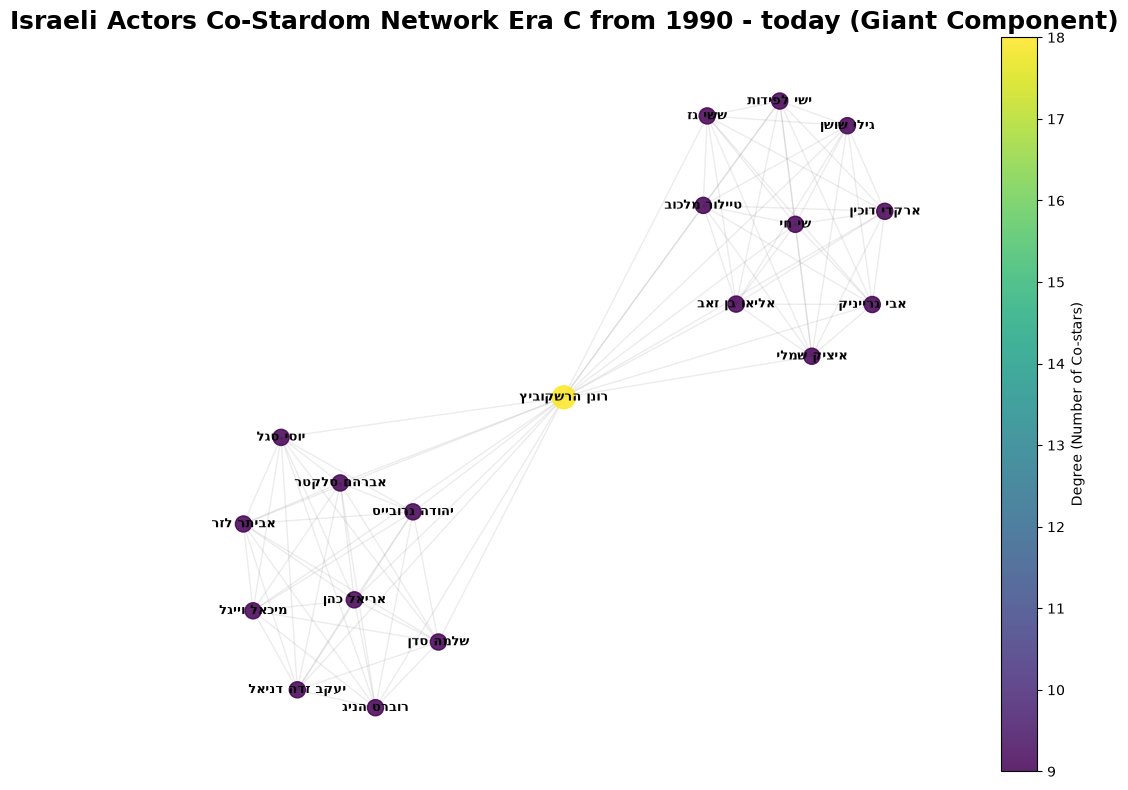

In [281]:
G_gcc_c = max(nx.connected_components(era_c), key=len)
gcc_c= G.subgraph(G_gcc_c).copy()

draw_graph(gcc_c,"Israeli Actors Co-Stardom Network Era C from 1990 - today (Giant Component)",(10,8))

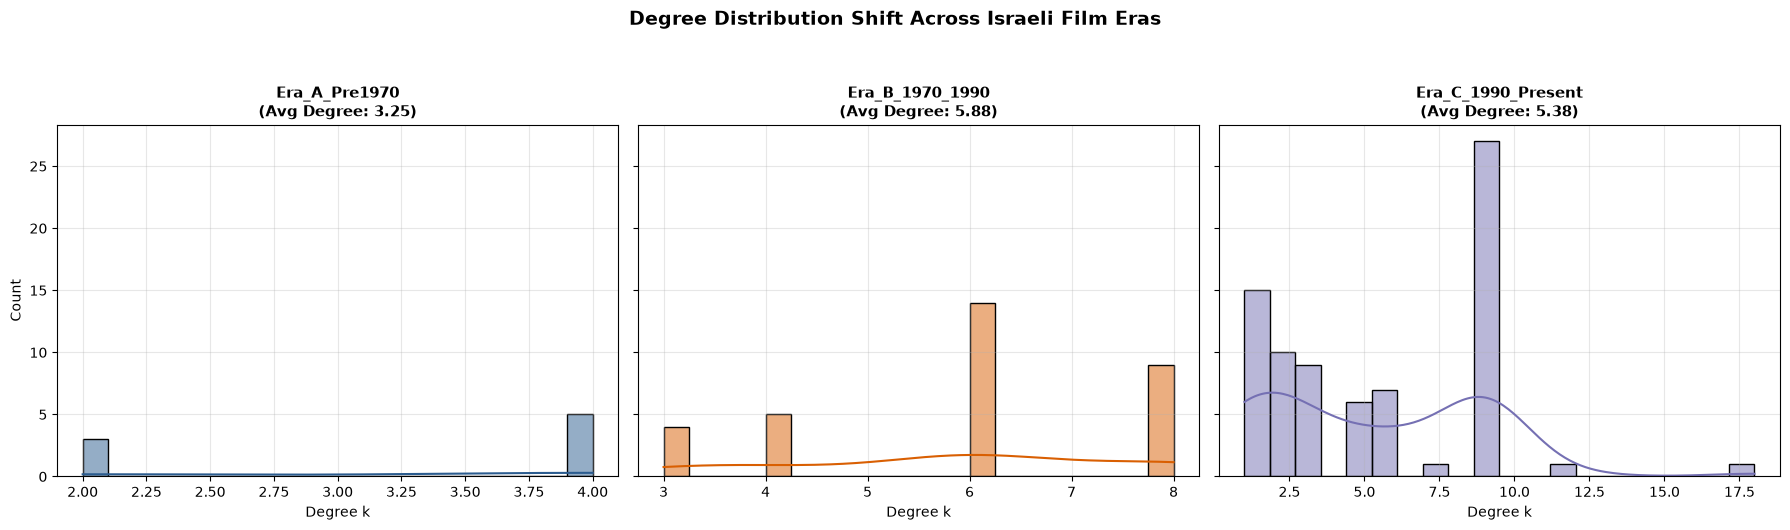

In [282]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
era_colors = {"Era_A_Pre1970": "#2b5c8f", "Era_B_1970_1990": "#d95f02", "Era_C_1990_Present": "#7570b3"}

for idx, (era_name, G_sub) in enumerate(subgraphs.items()):
    degrees = [d for _, d in G_sub.degree()]
    sns.histplot(degrees, kde=True, ax=axes[idx], color=era_colors[era_name], bins=20)
    axes[idx].set_title(f"{era_name}\n(Avg Degree: {df_metrics.loc[idx, 'Avg Degree <k>']})", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Degree k")
    axes[idx].set_ylabel("Count")
    axes[idx].grid(alpha=0.3)

plt.suptitle("Degree Distribution Shift Across Israeli Film Eras", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [283]:
from src.temporal_analysis import split_graph_by_eras
from src.community_analysis import run_community_detection_era_c, profile_communities
from src.centrality_analysis import compute_all_centralities, get_top_k_centrality_tables


if not os.path.exists(PROCESSED_CSV_PATH):
    raise FileNotFoundError(f"Missing input dataset: {PROCESSED_CSV_PATH}. Run Step 1 first.")

logging.info("Loading processed graph dataset...")
df_edges = pd.read_csv(PROCESSED_CSV_PATH)

# Reconstruct full graph
G_full = nx.Graph()
for _, row in df_edges.iterrows():
    G_full.add_edge(row["Source"], row["Target"], weight=row["Weight"], year=row["First_CoStar_Year"])

logging.info("--- Executing Step 3: Community Detection (Era C) ---")
subgraphs = split_graph_by_eras(df_edges)
G_era_c = subgraphs["Era_C_1990_Present"]

df_partitions, algo_results = run_community_detection_era_c(G_era_c)
df_profiles = profile_communities(G_era_c, df_partitions)

df_profiles.to_csv(COMMUNITY_PROFILES_CSV, index=False, encoding="utf-8-sig")
logging.info(f"Saved Community Profiles to {COMMUNITY_PROFILES_CSV}")

print("\n" + "="*80)
print("STEP 3: COMMUNITY DETECTION ALGORITHM COMPARISON (ERA C)")
print("="*80)
print(pd.DataFrame(algo_results).T.to_string())
print("\nTOP ERA C COMMUNITIES PROFILES:")
print(df_profiles.head(5).to_string(index=False))
print("="*80 + "\n")


2026-08-15 22:35:36,170 - INFO - Loading processed graph dataset...
2026-08-15 22:35:36,189 - INFO - --- Executing Step 3: Community Detection (Era C) ---
2026-08-15 22:35:36,193 - INFO - Sub-graph Era_A_Pre1970: 8 Nodes, 13 Edges
2026-08-15 22:35:36,198 - INFO - Sub-graph Era_B_1970_1990: 32 Nodes, 94 Edges
2026-08-15 22:35:36,208 - INFO - Sub-graph Era_C_1990_Present: 77 Nodes, 207 Edges
2026-08-15 22:35:36,220 - INFO - Community Detection Completed: Louvain Q=0.7753 (17 communities)
2026-08-15 22:35:36,244 - INFO - Saved Community Profiles to data/processed/era_c_community_profiles.csv



STEP 3: COMMUNITY DETECTION ALGORITHM COMPARISON (ERA C)
                   Modularity_Q  Num_Communities
Louvain                  0.7753             17.0
Greedy_Modularity        0.7670             16.0

TOP ERA C COMMUNITIES PROFILES:
 Community_ID  Size                                                    Top_Key_Actors
            8    10        רונן הרשקוביץ, אביתר לזר, מיכאל וייגל, שלמה סדן, אריאל כהן
            4    10    מוני מושונוב, אניה בוקשטיין, שרון סטרימבן, מגי אזרזר, רועי אסף
            9     9          אליאו בן זאב, שי חי, אבי גרייניק, גילי שושן, ארקדי דוכין
            6     8   חיים זנאתי, חיים בוזגלו, סמדר קילצ'ינסקי, עמוס לביא, צופית גרנט
           14     6 ג'ון בנג'מין היקי, ניב ניסים, ליהי קורנובסקי, מיקי קם, עמרי לוקאס



In [284]:
logging.info("--- Executing Step 4: Centrality Metrics Calculation ---")
df_centrality = compute_all_centralities(G_full)
df_centrality.to_csv(CENTRALITY_SUMMARY_CSV, index=False, encoding="utf-8-sig")

top_tables = get_top_k_centrality_tables(df_centrality, top_k=10)

print("\n" + "="*80)
print("STEP 4: TOP 10 ACTORS BY CENTRALITY METRICS")
print("="*80)
for metric_name, df_top in top_tables.items():
    print(f"\n--- Top 10: {metric_name} ---")
    print(df_top.to_string(index=False))
print("="*80 + "\n")

2026-08-15 22:35:36,258 - INFO - --- Executing Step 4: Centrality Metrics Calculation ---
2026-08-15 22:35:36,259 - INFO - Calculating Degree Centrality...
2026-08-15 22:35:36,260 - INFO - Calculating Betweenness Centrality...
2026-08-15 22:35:36,270 - INFO - Calculating Closeness Centrality...
2026-08-15 22:35:36,273 - INFO - Calculating Eigenvector Centrality...



STEP 4: TOP 10 ACTORS BY CENTRALITY METRICS

--- Top 10: Degree_Centrality ---
         Actor  Degree_Centrality  Degree
 רונן הרשקוביץ           0.156522      18
     עזרא כפרי           0.121739      14
  מוני מושונוב           0.104348      12
     גילי שושן           0.078261       9
יעקב זדה דניאל           0.078261       9
      יואב לוי           0.078261       9
     גל פרידמן           0.078261       9
   הלנה ירלובה           0.078261       9
     נטשה מנור           0.078261       9
     לירון לבו           0.078261       9

--- Top 10: Betweenness_Centrality ---
        Actor  Betweenness_Centrality  Degree
    עזרא כפרי                0.023799      14
 מוני מושונוב                0.019222      12
רונן הרשקוביץ                0.012357      18
   חיים זנאתי                0.000915       7
     תום אבני                0.000153       2
   אבי קושניר                0.000000       2
    אורי בנאי                0.000000       3
    ניצה שאול                0.000000       3
    

In [285]:
from src.temporal_analysis import split_graph_by_eras
from src.community_analysis import run_community_detection_era_c, profile_communities

df_edges = pd.read_csv("./data/processed/israeli_actors_edges.csv")
subgraphs = split_graph_by_eras(df_edges)
G_era_c = subgraphs["Era_C_1990_Present"]

# Run clustering algorithms
df_partitions, algo_comp = run_community_detection_era_c(G_era_c)
df_profiles = profile_communities(G_era_c, df_partitions)

print("Algorithm Comparison:")
display(pd.DataFrame(algo_comp).T)

print("\nCommunity Profiles (Louvain):")
display(df_profiles.style.background_gradient(cmap="Blues", subset=["Size"]))

2026-08-15 22:35:36,367 - INFO - Sub-graph Era_A_Pre1970: 8 Nodes, 13 Edges
2026-08-15 22:35:36,375 - INFO - Sub-graph Era_B_1970_1990: 32 Nodes, 94 Edges
2026-08-15 22:35:36,385 - INFO - Sub-graph Era_C_1990_Present: 77 Nodes, 207 Edges
2026-08-15 22:35:36,397 - INFO - Community Detection Completed: Louvain Q=0.7753 (17 communities)


Algorithm Comparison:


,Modularity_Q,Num_Communities
Louvain,0.7753,17.0
Greedy_Modularity,0.7670,16.0



Community Profiles (Louvain):


,Community_ID,Size,Top_Key_Actors
8,8,10,"רונן הרשקוביץ, אביתר לזר, מיכאל וייגל, שלמה סדן, אריאל כהן"
4,4,10,"מוני מושונוב, אניה בוקשטיין, שרון סטרימבן, מגי אזרזר, רועי אסף"
9,9,9,"אליאו בן זאב, שי חי, אבי גרייניק, גילי שושן, ארקדי דוכין"
6,6,8,"חיים זנאתי, חיים בוזגלו, סמדר קילצ'ינסקי, עמוס לביא, צופית גרנט"
14,14,6,"ג'ון בנג'מין היקי, ניב ניסים, ליהי קורנובסקי, מיקי קם, עמרי לוקאס"
5,5,6,"עזרא כפרי, כרמל בתו, ליילה מלקוס, אייל שכטר, לי את גליק"
12,12,4,"דובי גל, ניצה שאול, אורי בנאי, מריה אובנוב"
13,13,3,"יוסי מרשק, שמואל קלדרון, סמנתה אגר"
10,10,3,"תום אבני, הילה וידור, הילה סעדה"
0,0,3,"אבי קושניר, אפרת בן צור, גיל פרנק"


In [286]:
from src.centrality_analysis import compute_all_centralities, get_top_k_centrality_tables

# Compute centralities on full graph
df_centrality = compute_all_centralities(G)
top_tables = get_top_k_centrality_tables(df_centrality, top_k=10)

# Display Top 10 for Degree and Betweenness Centralities side by side
df_deg = top_tables["Degree_Centrality"].reset_index(drop=True)
df_bet = top_tables["Betweenness_Centrality"].reset_index(drop=True)

df_combined = pd.concat([df_deg, df_bet], axis=1, keys=["Degree Centrality (Prolific Stars)", "Betweenness (Bridge Actors)"])
display(df_combined)

2026-08-15 22:35:36,421 - INFO - Calculating Degree Centrality...
2026-08-15 22:35:36,422 - INFO - Calculating Betweenness Centrality...
2026-08-15 22:35:36,434 - INFO - Calculating Closeness Centrality...
2026-08-15 22:35:36,436 - INFO - Calculating Eigenvector Centrality...


Degree Centrality (Prolific Stars)                           \
                               Actor Degree_Centrality Degree   
0                      רונן הרשקוביץ          0.156522     18   
1                          עזרא כפרי          0.121739     14   
2                       מוני מושונוב          0.104348     12   
3                          גילי שושן          0.078261      9   
4                     יעקב זדה דניאל          0.078261      9   
5                           יואב לוי          0.078261      9   
6                          גל פרידמן          0.078261      9   
7                        הלנה ירלובה          0.078261      9   
8                          נטשה מנור          0.078261      9   
9                          לירון לבו          0.078261      9   

  Betweenness (Bridge Actors)                                
                        Actor Betweenness_Centrality Degree  
0                   עזרא כפרי               0.023799     14  
1                מוני מושונוב               0.019222     12  
2               רונן הרשקוביץ               0.012357     18  
3                  חיים זנאתי               0.000915      7  
4                    תום אבני               0.000153      2  
5                  אבי קושניר               0.000000      2  
6                   אורי בנאי               0.000000      3  
7                   ניצה שאול               0.000000      3  
8                     דובי גל               0.000000      3  
9                 נטע שפיגלמן               0.000000      1

In [287]:
from sklearn.model_selection import train_test_split
from src.link_prediction import (
    create_temporal_splits, 
    prepare_dataset, 
    train_and_evaluate_model, 
    perform_error_analysis
)


logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


if not os.path.exists(PROCESSED_CSV_PATH):
    raise FileNotFoundError(f"Missing input dataset: {PROCESSED_CSV_PATH}. Run Step 1 first.")

logging.info("--- Executing Step 5: Link Prediction Machine Learning Engine ---")
df_edges = pd.read_csv(PROCESSED_CSV_PATH)

# 1. Temporal Data Split (G_train <= 2020, Future edges 2021-2025; falls back dynamically if sparse)
G_train, E_test_pos = create_temporal_splits(df_edges, train_cutoff_year=2020)

# 2. Build Dataset & Extract Features
logging.info("Extracting topological and embedding features...")
df_dataset, X, y = prepare_dataset(G_train, E_test_pos, neg_ratio=1.0)

if len(X) == 0:
    raise ValueError("Extracted feature matrix X is empty. Verify input edges dataset.")

# 3. Train/Test Split (handles small datasets safely)
test_size = 0.3 if len(X) >= 20 else 0.2

# Stratify only if both classes have enough samples
stratify_target = y if len(set(y)) > 1 and min(pd.Series(y).value_counts()) >= 2 else None

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_dataset.index, test_size=test_size, random_state=42, stratify=stratify_target
)

df_test = df_dataset.loc[idx_test].copy()

# 4. Train Model & Evaluate
logging.info("Training Random Forest link prediction classifier...")
clf, metrics, y_proba = train_and_evaluate_model(X_train, y_train, X_test, y_test)

# Export Metrics
os.makedirs("data/processed", exist_ok=True)
pd.DataFrame([metrics]).to_csv(MODEL_METRICS_PATH, index=False)
logging.info(f"Saved evaluation metrics to {MODEL_METRICS_PATH}")

# 5. Perform Qualitative Error Analysis
error_analysis_results = perform_error_analysis(df_test, y_proba, top_k=5)

print("\n" + "="*80)
print("STEP 5: LINK PREDICTION EVALUATION METRICS")
print("="*80)
for k, v in metrics.items():
    print(f"{k:20s}: {v}")
print("="*80)

print("\n" + "="*80)
print("QUALITATIVE ERROR ANALYSIS (TOP INSTANCES)")
print("="*80)

print("\n--- Top Realized Predictions (True Positives) ---")
print(error_analysis_results["Top_True_Positives"].to_string(index=False))

print("\n--- Strong Predictions That Didn't Materialize (False Positives) ---")
print(error_analysis_results["Top_False_Positives"].to_string(index=False))

print("\n--- Missed Realized Links (False Negatives) ---")
print(error_analysis_results["Top_False_Negatives"].to_string(index=False))
print("="*80 + "\n")



2026-08-15 22:35:36,527 - INFO - --- Executing Step 5: Link Prediction Machine Learning Engine ---
2026-08-15 22:35:36,956 - WARNING - Could not find a valid temporal cutoff year with sufficient future co-stardom edges. Falling back to random edge-masking split.
2026-08-15 22:35:37,075 - INFO - Using Random Edge Split | G_train Edges: 252 | Ground-Truth Test Edges: 62
2026-08-15 22:35:37,076 - INFO - Extracting topological and embedding features...
2026-08-15 22:35:37,212 - INFO - Training Random Forest link prediction classifier...
2026-08-15 22:35:37,837 - INFO - Saved evaluation metrics to data/processed/link_prediction_metrics.csv



STEP 5: LINK PREDICTION EVALUATION METRICS
Precision           : 0.9
Recall              : 0.9474
F1_Score            : 0.9231
ROC_AUC             : 0.9668

QUALITATIVE ERROR ANALYSIS (TOP INSTANCES)

--- Top Realized Predictions (True Positives) ---
                u            v  prediction_score  common_neighbors  jaccard
    יהודה גרובייס  מיכאל וייגל               1.0                 6     0.75
        מגי אזרזר     רועי אסף               1.0                 6     0.75
ג'ון בנג'מין היקי    ניב ניסים               1.0                 2     0.50
       יוסף שילוח מרדכי בן זאב               1.0                 3     0.60
        גל פרידמן    לירון לבו               1.0                 6     0.75

--- Strong Predictions That Didn't Materialize (False Positives) ---
            u           v  prediction_score  common_neighbors  jaccard
    יוסי גרבר ליילה מלקוס          0.920000                 1 0.142857
   הגר בן אשר  אבי גילאור          0.710000                 0 0.000000
רונן הרשק

In [288]:
from src.link_prediction import create_temporal_splits, prepare_dataset

df_edges = pd.read_csv("./data/processed/israeli_actors_edges.csv")

# 1. Temporal Split (Cutoff at 2020)
G_train, E_test_pos = create_temporal_splits(df_edges, train_cutoff_year=2020)

# 2. Extract Features
df_dataset, X, y = prepare_dataset(G_train, E_test_pos, neg_ratio=1.0)
print(f"Dataset Feature Matrix Shape: {X.shape}")
display(X.head())

2026-08-15 22:35:38,480 - WARNING - Could not find a valid temporal cutoff year with sufficient future co-stardom edges. Falling back to random edge-masking split.
2026-08-15 22:35:38,496 - INFO - Using Random Edge Split | G_train Edges: 252 | Ground-Truth Test Edges: 62


Dataset Feature Matrix Shape: (124, 8)


,common_neighbors,jaccard,adamic_adar,preferential_attachment,shortest_path,deg_centrality_prod,bet_centrality_prod,embedding_similarity
0,3,0.750000,2.064030,12,2,0.000907,0.000000e+00,0.999998
1,1,0.250000,0.621335,6,2,0.000454,0.000000e+00,0.999866
2,4,0.571429,2.017426,30,2,0.002268,5.678641e-08,0.999901
3,0,0.000000,0.000000,2,99,0.000151,0.000000e+00,-0.062084
4,6,0.750000,2.823636,48,2,0.003629,4.870995e-09,0.961701


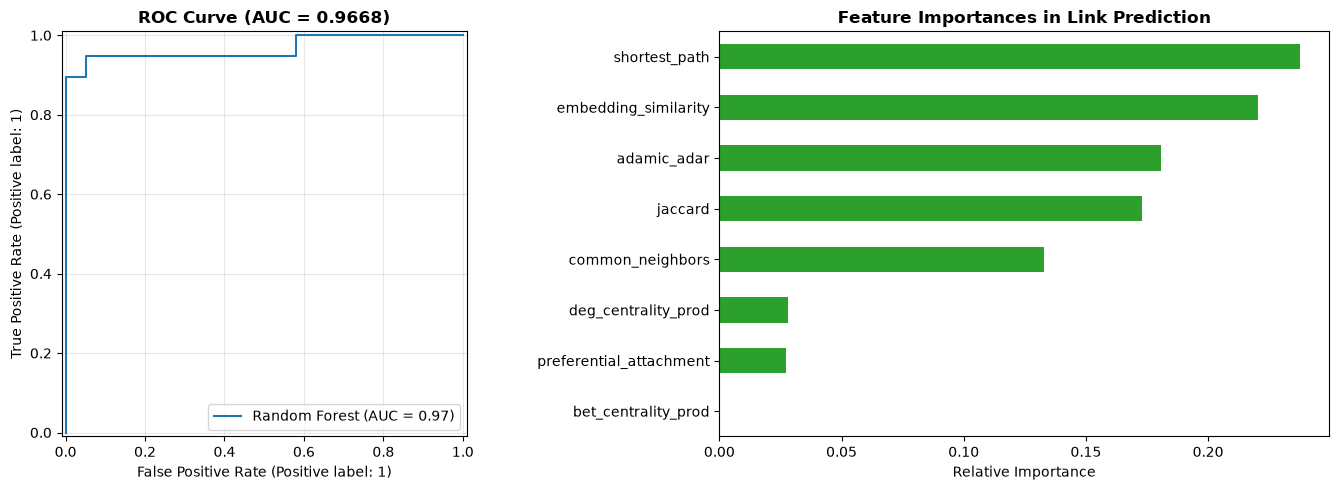


Top Predicted Future Co-Stardom Links (True Positives):


,u,v,prediction_score,common_neighbors,jaccard
89,יהודה גרובייס,מיכאל וייגל,1.0,6,0.75
23,מגי אזרזר,רועי אסף,1.0,6,0.75
72,ג'ון בנג'מין היקי,ניב ניסים,1.0,2,0.50
16,יוסף שילוח,מרדכי בן זאב,1.0,3,0.60
82,גל פרידמן,לירון לבו,1.0,6,0.75


In [289]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay
from src.link_prediction import train_and_evaluate_model, perform_error_analysis

# Split & Train
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_dataset.index, test_size=0.3, random_state=42, stratify=y
)
clf, metrics, y_proba = train_and_evaluate_model(X_train, y_train, X_test, y_test)

# Plot ROC Curve and Feature Importance side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name="Random Forest")
axes[0].set_title(f"ROC Curve (AUC = {metrics['ROC_AUC']})", fontweight="bold")
axes[0].grid(alpha=0.3)

# 2. Feature Importance
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind="barh", ax=axes[1], color="#2ca02c")
axes[1].set_title("Feature Importances in Link Prediction", fontweight="bold")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

# Display Error Analysis Tables
df_test = df_dataset.loc[idx_test].copy()
analysis = perform_error_analysis(df_test, y_proba, top_k=5)

print("\nTop Predicted Future Co-Stardom Links (True Positives):")
display(analysis["Top_True_Positives"])